In [2]:
import os
os.chdir("D:/文章返修/source data/Figure_2/Panel_A")
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import fcluster
import pandas as pd

In [3]:
def classify_rna_data(input_rna, dis, freq, binsize, discard):
    data = input_rna.copy()
    distance = data['E'] - data['S']
    rna_long = data[distance >= dis]
    rna_long_hf = rna_long[rna_long['value'] > freq]
    
    mask_c = (rna_long_hf['S'] <= discard[0]) & (rna_long_hf['value']>discard[1])
    
    hist_data = []
    s = 0
    e = binsize
    lens = data['E'].max()
    while True:
        distance_hf = rna_long_hf[~mask_c]['E'] - rna_long_hf[~mask_c]['S']
        mask = (distance_hf >= s) & (distance_hf <= e)
        hist_data.append(rna_long_hf[~mask_c]['value'][mask].sum())
        s = e
        e += binsize
        if e >= lens:
            break
    
    return rna_long_hf[mask_c], rna_long_hf[~mask_c], hist_data

([<matplotlib.axis.YTick at 0x1d9ffcdfce0>,
 [Text(0, 0.5, 'Short-range'),
  Text(0, 1.5, 'Mid-range'),
  Text(0, 2.5, 'Long-range')])

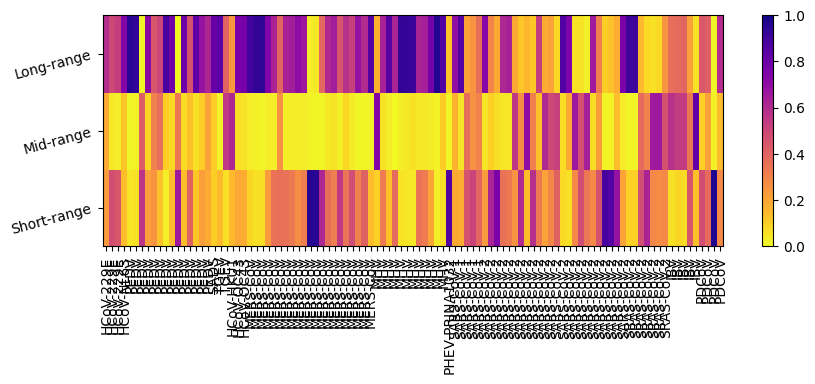

In [4]:
file_dir = 'D:/文章返修/RNAseq/matrix/available/'
file_list = os.listdir(file_dir)
counts_array = np.zeros(len(file_list), dtype=[('Name','U14'),('C','<f8'),('NC','<f8')])
nc_classify = np.zeros(len(file_list), dtype=[('Name','U14'),('short','<f8'),('mid','<f8'),('long','<f8')])
df_sum = np.zeros(len(file_list), dtype=[('Name','U50'),('C','<i4'),('NC','<i4'),('short','<i4'),('mid','<i4'),('long','<i4')])
for i,file_name in enumerate(file_list):
    recom_data = np.loadtxt(file_dir +  file_name, usecols=[0,1,2], dtype=[('S','<f8'),('E','<f8'),('value','<f8')])
    min_value = min(2000, recom_data['value'].max() / 100)
    rna_c, rna_nc, hist_data = classify_rna_data(recom_data, 100, 10, 100, [100, min_value])
    total_c = rna_c['value'].sum()
    total_nc = rna_nc['value'].sum()
    total = total_c + total_nc
    counts_array[i][0] = file_name.split('_')[2] #.split('-')[0]
    counts_array[i][1] = total_c / total
    counts_array[i][2] = total_nc / total
    nc_classify[i][0] = counts_array[i][0]
    nc_classify[i][1] = sum(hist_data[0:50]) / total_nc
    nc_classify[i][2] = sum(hist_data[50:200]) / total_nc
    nc_classify[i][3] = sum(hist_data[200:]) / total_nc
    df_sum[i][0] = '_'.join([file_name.split('_')[1], '-'.join(file_name.split('_')[2].split('-')[:-1]), file_name.split('_')[-1].split('.')[0]])
    df_sum[i][1] = total_c
    df_sum[i][2] = total_nc
    df_sum[i][3] = sum(hist_data[0:50])
    df_sum[i][4] = sum(hist_data[50:200])
    df_sum[i][5] = sum(hist_data[200:])

plt.figure(figsize=(10,3)) 
plt.pcolor(np.vstack([nc_classify['short'], nc_classify['mid'], nc_classify['long']]), cmap=plt.get_cmap('plasma_r'), vmax = 1, vmin = 0)
plt.colorbar()   
plt.xticks(np.arange(counts_array.shape[0])+0.5, counts_array['Name'], rotation = 90)
plt.yticks([0.5,1.5,2.5], ['Short-range', 'Mid-range', 'Long-range'], rotation = 15)

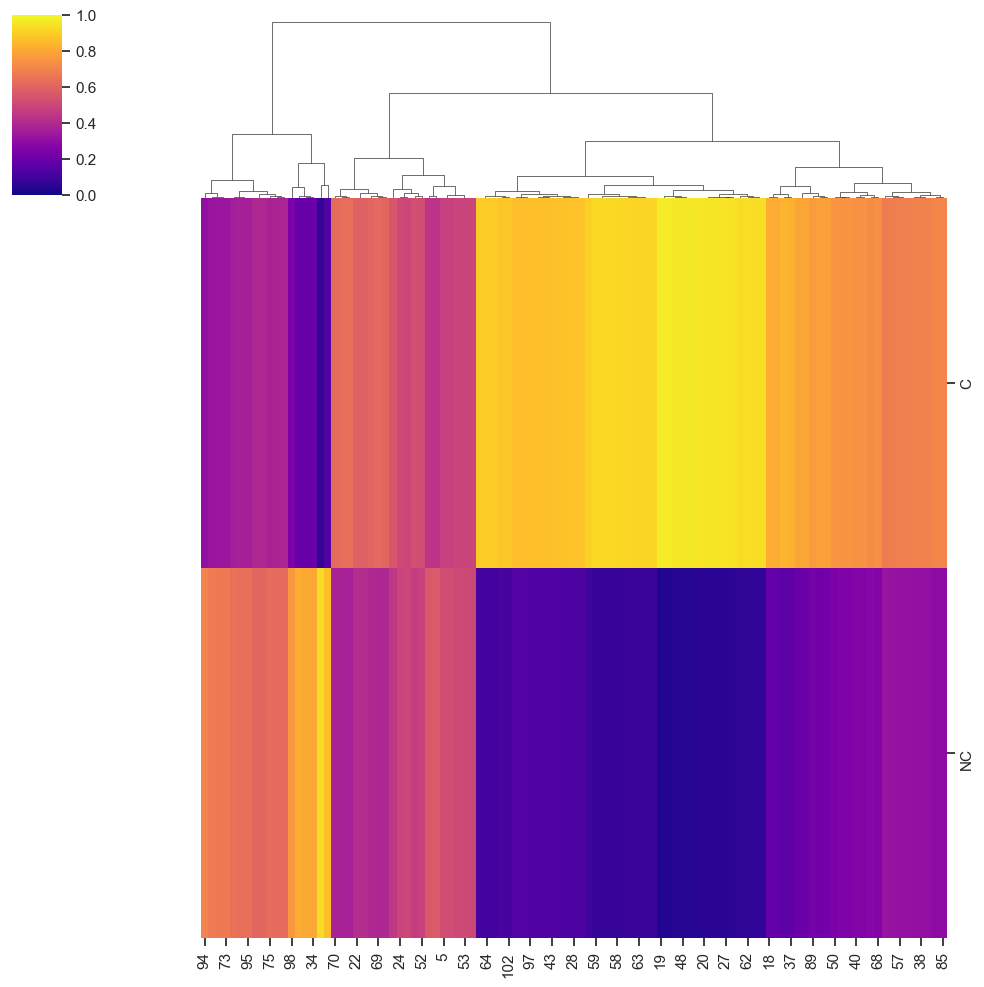

In [5]:
sns.set_theme(style="ticks")    
input_data = [counts_array['C'], counts_array['NC']]
cluster = sns.clustermap(data= input_data, cmap=plt.get_cmap('plasma'), yticklabels= ['C','NC'], row_cluster=0, vmax = 1, vmin = 0, method='complete') 
row_linkage = cluster.dendrogram_col.linkage
clusters = fcluster(row_linkage, t=3, criterion='maxclust')

In [6]:
df = pd.DataFrame({
    'canonical': counts_array['C'],
    'non-canonical':   counts_array['NC'],
    'Virus':  counts_array['Name'],
    'Cluster': clusters
})
df.to_excel('Clustering of canonical and non-canonical transcription events.xlsx', index=False)